In [1]:
# filename is /lustre/ARUN/user/thunthita/frpday
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import linregress

# Open datasets
gfas_fire_xrS3A_D = xr.open_mfdataset('/lustre/ARUN/user/thunthita/realday2022/*-C3S-L3-FRP-SLSTR-P1D-0.1deg-S3A-daytime-fv1.2.nc', combine='by_coords', engine='netcdf4')
gfas_fire_xrS3B_D = xr.open_mfdataset('/lustre/ARUN/user/thunthita/realday2022/*-C3S-L3-FRP-SLSTR-P1D-0.1deg-S3B-daytime-fv1.2.nc', combine='by_coords', engine='netcdf4')

In [2]:
gfas_fire_xrS3A_N = xr.open_mfdataset('/lustre/ARUN/user/thunthita/realnight2022/*-C3S-L3-FRP-SLSTR-P1D-0.1deg-S3A-nighttime-fv1.2.nc', combine='by_coords', engine='netcdf4')
gfas_fire_xrS3B_N = xr.open_mfdataset('/lustre/ARUN/user/thunthita/realnight2022/*-C3S-L3-FRP-SLSTR-P1D-0.1deg-S3B-nighttime-fv1.2.nc', combine='by_coords', engine='netcdf4')

In [3]:
gfas_fire_xrS3B_N

<xarray.Dataset> Size: 227GB
Dimensions:                            (time: 729, lon: 3600, bounds: 2,
                                        lat: 1800)
Coordinates:
  * lon                                (lon) float32 14kB -179.9 ... 179.9
  * lat                                (lat) float32 7kB 89.95 89.85 ... -89.95
  * time                               (time) datetime64[ns] 6kB 2022-02-27 ....
Dimensions without coordinates: bounds
Data variables:
    lon_bounds                         (time, lon, bounds) float32 21MB dask.array<chunksize=(1, 3600, 2), meta=np.ndarray>
    lat_bounds                         (time, lat, bounds) float32 10MB dask.array<chunksize=(1, 1800, 2), meta=np.ndarray>
    time_bounds                        (time, bounds) datetime64[ns] 12kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    fire_pixels                        (time, lat, lon) float64 38GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
    frp                                (time, lat, lon) float32 19GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
    frp_unc                            (time, lat, lon) float32 19GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
    total_pixels                       (time, lat, lon) float64 38GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
    surface_conditions_flag_pixels     (time, lat, lon) float64 38GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
    atmospheric_condition_flag_pixels  (time, lat, lon) float64 38GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
    atmospheric_condition_fraction     (time, lat, lon) float32 19GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
    fire_weighted_pixels               (time, lat, lon) float32 19GB dask.array<chunksize=(1, 18, 3600), meta=np.ndarray>
Attributes: (12/40)
    title:                      ECMWF C3S Gridded OLCI Fire Radiative Power p...
    institution:                King's College London, Brockmann Consult GmbH
    source:                     ESA Sentinel-3 A+B SLSTR FRP
    history:                    Created on 20221215T192358Z
    references:                 See https://climate.copernicus.eu/
    tracking_id:                e0c7d508-4631-45bc-ae05-b00a108ab00e
    ...                         ...
    sensor:                     SLSTR
    spatial_resolution:         0.1 degrees
    geospatial_lon_units:       degrees_east
    geospatial_lat_units:       degrees_north
    geospatial_lon_resolution:  0.1
    geospatial_lat_resolution:  0.1

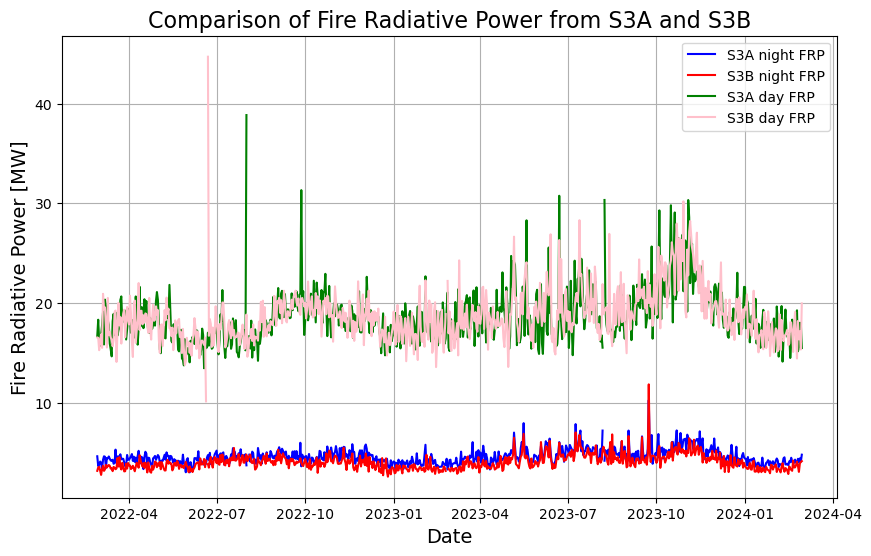

In [4]:
# Plotting FRP from S3A and S3B
plt.figure(figsize=(10, 6))
plt.plot(gfas_fire_xrS3A_N['time'], gfas_fire_xrS3A_N['frp'].mean(dim=['lat', 'lon']), label='S3A night FRP', color='blue')
plt.plot(gfas_fire_xrS3B_N['time'], gfas_fire_xrS3B_N['frp'].mean(dim=['lat', 'lon']), label='S3B night FRP', color='red')
plt.plot(gfas_fire_xrS3A_D['time'], gfas_fire_xrS3A_D['frp'].mean(dim=['lat', 'lon']), label='S3A day FRP', color='green')
plt.plot(gfas_fire_xrS3B_D['time'], gfas_fire_xrS3B_D['frp'].mean(dim=['lat', 'lon']), label='S3B day FRP', color='pink')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Fire Radiative Power [MW]', fontsize=14)
plt.title('Comparison of Fire Radiative Power from S3A and S3B', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

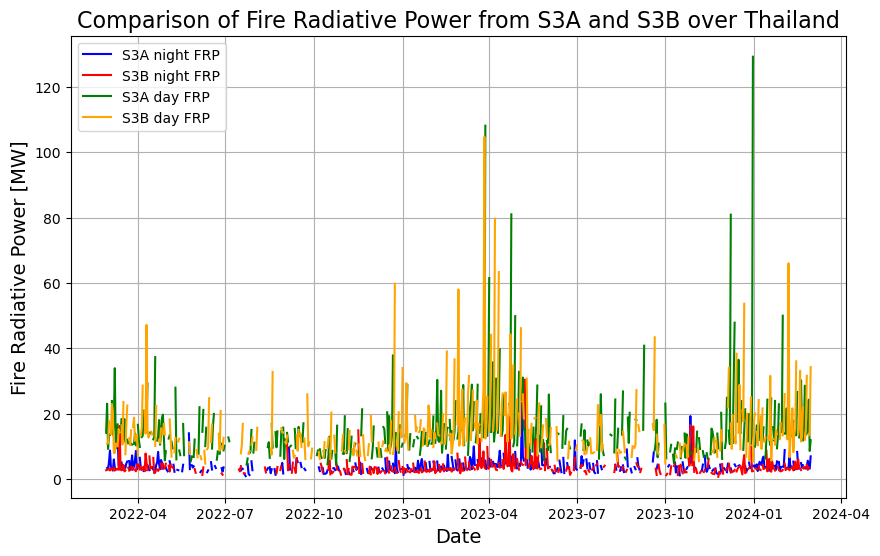

In [5]:
# Plotting FRP from S3A and S3B
plt.figure(figsize=(10, 6))
plt.plot(gfas_fire_xrS3A_N['time'], gfas_fire_xrS3A_N['frp'].sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).mean(dim=['lat', 'lon']), label='S3A night FRP', color='blue')
plt.plot(gfas_fire_xrS3B_N['time'], gfas_fire_xrS3B_N['frp'].sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).mean(dim=['lat', 'lon']), label='S3B night FRP', color='red')
plt.plot(gfas_fire_xrS3A_D['time'], gfas_fire_xrS3A_D['frp'].sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).mean(dim=['lat', 'lon']), label='S3A day FRP', color='green')
plt.plot(gfas_fire_xrS3B_D['time'], gfas_fire_xrS3B_D['frp'].sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).mean(dim=['lat', 'lon']), label='S3B day FRP', color='orange')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Fire Radiative Power [MW]', fontsize=14)
plt.title('Comparison of Fire Radiative Power from S3A and S3B over Thailand', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

In [6]:
#fwi_dataset = xr.open_mfdataset('/lustre/ARUN/user/thunthita/FWI2022-2024/eur11_rca4_MOHC-HadGEM2-ES_rcp26_fwi-daily-proj_202*0101_202*1230_v2.nc', combine='by_coords', engine='netcdf4')

In [7]:
#this is EU zone only
#fwi_dataset

In [8]:
# Define a function to set time to 00:00:00
def set_time_to_midnight(ds):
    ds['time'] = pd.to_datetime(ds['time'].dt.floor('D'))
    return ds
    
# Apply the function to each dataset
gfas_fire_xrS3A_D = set_time_to_midnight(gfas_fire_xrS3A_D)
gfas_fire_xrS3A_N = set_time_to_midnight(gfas_fire_xrS3A_N)                                        
gfas_fire_xrS3B_D = set_time_to_midnight(gfas_fire_xrS3B_D)
gfas_fire_xrS3B_N = set_time_to_midnight(gfas_fire_xrS3B_N)

# Subset data to match the time range of FRP data
time_range = slice('2022-01-01', '2024-02-28')
frps3a_D = gfas_fire_xrS3A_D['frp'].sel(time=time_range)
frps3b_D = gfas_fire_xrS3B_D['frp'].sel(time=time_range)
frps3a_N = gfas_fire_xrS3A_N['frp'].sel(time=time_range)
frps3b_N = gfas_fire_xrS3B_N['frp'].sel(time=time_range)
fires3a_D = gfas_fire_xrS3A_D['fire_pixels'].sel(time=time_range)
fires3b_D = gfas_fire_xrS3B_D['fire_pixels'].sel(time=time_range)
fires3a_N = gfas_fire_xrS3A_N['fire_pixels'].sel(time=time_range)
fires3b_N = gfas_fire_xrS3B_N['fire_pixels'].sel(time=time_range)

# Select subsets
subset_frps3a_D = frps3a_D.sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5))
subset_frps3a_N = frps3a_N.sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5))
subset_frps3b_D = frps3b_D.sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5))
subset_frps3b_N = frps3b_N.sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5))

subset_fires3a_D = fires3a_D.sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5))
subset_fires3a_N = fires3a_N.sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5))
subset_fires3b_D = fires3b_D.sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5))
subset_fires3b_N = fires3b_N.sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5))

# Align datasets
aligned_frps3a_D, aligned_frps3b_D = xr.align(subset_frps3a_D, subset_frps3b_D, join='outer', fill_value=0)
aligned_frps3a_N, aligned_frps3b_N = xr.align(subset_frps3a_N, subset_frps3b_N, join='outer', fill_value=0)
aligned_fires3a_D, aligned_fires3b_D = xr.align(subset_fires3a_D, subset_fires3b_D, join='outer', fill_value=0)
aligned_fires3a_N, aligned_fires3b_N = xr.align(subset_fires3a_N, subset_fires3b_N, join='outer', fill_value=0)

# Combine FRP values respecting NaN conditions
frp_combined_D = xr.where(
    aligned_frps3a_D.notnull() & aligned_frps3b_D.isnull(),  # Only frp3a is not NaN
    aligned_frps3a_D,                                         # Take frp3a
    xr.where(
        aligned_frps3a_D.isnull() & aligned_frps3b_D.notnull(),  # Only frp3b is not NaN
        aligned_frps3b_D,                                       # Take frp3b
        (aligned_frps3a_D + aligned_frps3b_D) / 2                 # Average of frp3a and frp3b
    )
).fillna(np.nan)  # Use NaN for cases where both are NaN

frp_combined_N = xr.where(
    aligned_frps3a_N.notnull() & aligned_frps3b_N.isnull(),  # Only frp3a is not NaN
    aligned_frps3a_N,                                         # Take frp3a
    xr.where(
        aligned_frps3a_N.isnull() & aligned_frps3b_N.notnull(),  # Only frp3b is not NaN
        aligned_frps3b_N,                                       # Take frp3b
        (aligned_frps3a_N + aligned_frps3b_N) / 2                 # Average of frp3a and frp3b
    )
).fillna(np.nan)  # Use NaN for cases where both are NaN

# Combine fire pixel data respecting NaN conditions
fire_combined_D = xr.where(
    aligned_fires3a_D.notnull() & aligned_fires3b_D.isnull(),  # Only fire3a is not NaN
    aligned_fires3a_D,                                         # Take fire3a
    xr.where(
        aligned_fires3a_D.isnull() & aligned_fires3b_D.notnull(),  # Only fire3b is not NaN
        aligned_fires3b_D,                                       # Take fire3b
        (aligned_fires3a_D + aligned_fires3b_D) / 2                 # Average of fire3a and fire3b
    )
).fillna(np.nan)  # Use NaN for cases where both are NaN

# Similarly, for fire_combined_N
fire_combined_N = xr.where(
    aligned_fires3a_N.notnull() & aligned_fires3b_N.isnull(),  # Only fire3a is not NaN
    aligned_fires3a_N,                                         # Take fire3a
    xr.where(
        aligned_fires3a_N.isnull() & aligned_fires3b_N.notnull(),  # Only fire3b is not NaN
        aligned_fires3b_N,                                       # Take fire3b
        (aligned_fires3a_N + aligned_fires3b_N) / 2                 # Average of fire3a and fire3b
    )
).fillna(np.nan)  # Use NaN for cases where both are NaN


# Compute means
mean_frp_D = frp_combined_D.mean(dim=['lat', 'lon'])
mean_frp_N = frp_combined_N.mean(dim=['lat', 'lon'])
mean_fire_D = fire_combined_D.mean(dim=['lat', 'lon'])
mean_fire_N = fire_combined_N.mean(dim=['lat', 'lon'])

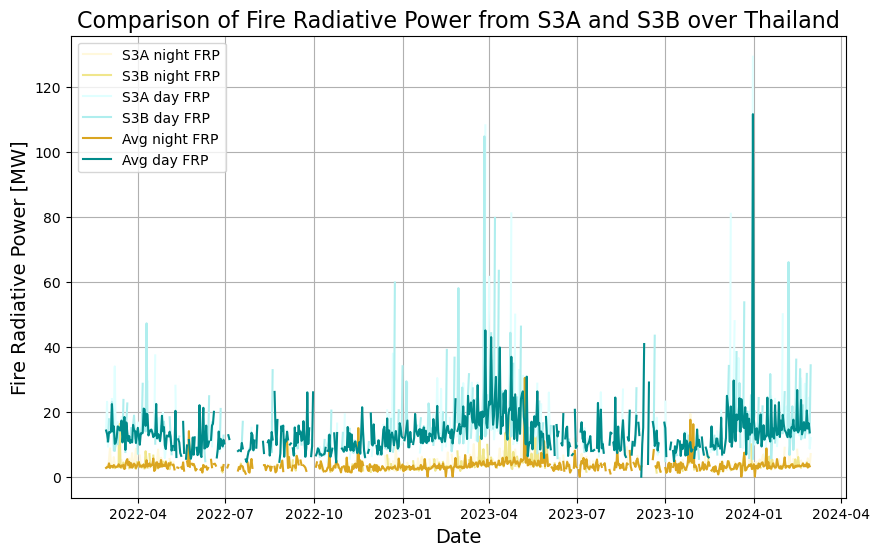

In [9]:
# Plotting FRP from S3A and S3B
plt.figure(figsize=(10, 6))
plt.plot(gfas_fire_xrS3A_N['time'], gfas_fire_xrS3A_N['frp'].sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).mean(dim=['lat', 'lon']), label='S3A night FRP', color='cornsilk')
plt.plot(gfas_fire_xrS3B_N['time'], gfas_fire_xrS3B_N['frp'].sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).mean(dim=['lat', 'lon']), label='S3B night FRP', color='khaki')
plt.plot(gfas_fire_xrS3A_D['time'], gfas_fire_xrS3A_D['frp'].sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).mean(dim=['lat', 'lon']), label='S3A day FRP', color='lightcyan')
plt.plot(gfas_fire_xrS3B_D['time'], gfas_fire_xrS3B_D['frp'].sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).mean(dim=['lat', 'lon']), label='S3B day FRP', color='paleturquoise')
plt.plot(mean_frp_N['time'], mean_frp_N, label='Avg night FRP', color='goldenrod')
plt.plot(mean_frp_D['time'], mean_frp_D, label='Avg day FRP', color='darkcyan')

plt.xlabel('Date', fontsize=14)
plt.ylabel('Fire Radiative Power [MW]', fontsize=14)
plt.title('Comparison of Fire Radiative Power from S3A and S3B over Thailand', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()


In [10]:
mean_frp_N.sel(time='2022-08-16').load()

<xarray.DataArray 'frp' ()> Size: 4B
array(3.0598958, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2022-08-16

In [11]:
gfas_fire_xrS3A_N['frp'].sel(time='2022-08-16').sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).mean(dim=['lat', 'lon']).load()

<xarray.DataArray 'frp' ()> Size: 4B
array(3.6512895, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2022-08-16

In [12]:
gfas_fire_xrS3B_N['frp'].sel(time='2022-08-16').sel(lat=slice(20.5, 5.5), lon=slice(97.5, 105.5)).mean(dim=['lat', 'lon']).load()

<xarray.DataArray 'frp' ()> Size: 4B
array(2.320654, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2022-08-16

In [13]:
mean_frp_D.sel(time='2022-08-16').load()

<xarray.DataArray 'frp' ()> Size: 4B
array(6.5148277, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2022-08-16